
# Datathon 2026


In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings('ignore')

# ==========================================
# 1. CẤU HÌNH & LOAD DỮ LIỆU
# ==========================================
DIR = '../data/'
if not os.path.exists(DIR):
    DIR = ''

TRAIN_FILE = DIR + 'sales.csv'
TEST_FILE  = DIR + 'sample_submission.csv'

train_df = pd.read_csv(TRAIN_FILE, parse_dates=['Date'])
train_df = train_df.sort_values('Date').reset_index(drop=True)
test_df  = pd.read_csv(TEST_FILE,  parse_dates=['Date'])



## 2. Feature Engineering (Occam's Razor)



In [4]:
def create_features(df):
    df = df.copy()
    df['year']       = df['Date'].dt.year
    df['month']      = df['Date'].dt.month
    df['day']        = df['Date'].dt.day
    df['dayofweek']  = df['Date'].dt.dayofweek
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    df['dayofyear']  = df['Date'].dt.dayofyear
    df['quarter']    = df['Date'].dt.quarter

    # Insight 1 - Payday Effect
    df['is_payday']  = df['day'].isin([1, 2, 3, 28, 29, 30, 31]).astype(int)

    # Insight 2 - Cyclic Encoding
    df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12.0)
    df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12.0)

    return df

X_train_full = create_features(train_df)
X_test       = create_features(test_df)

FEATURES = [
    'year', 'month', 'day', 'dayofweek', 'is_weekend',
    'dayofyear', 'quarter', 'is_payday', 'month_sin', 'month_cos'
]

TARGET_REV  = 'Revenue'
TARGET_COGS = 'COGS'



## 3. Metrics Helpers


In [5]:
def calculate_wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

def print_metrics_table(metrics_per_fold: dict, target_name: str, model_name: str):
    print(f"\n--- KẾT QUẢ CV {model_name} - {target_name.upper()} ---")
    n_folds = len(metrics_per_fold['WAPE'])
    for i in range(n_folds):
        print(f"Fold {i+1}: WAPE={metrics_per_fold['WAPE'][i]:.2%} | MAE={metrics_per_fold['MAE'][i]:,.0f} | RMSE={metrics_per_fold['RMSE'][i]:,.0f}")
    print(f"MEAN: WAPE={np.mean(metrics_per_fold['WAPE']):.2%} | MAE={np.mean(metrics_per_fold['MAE']):,.0f} | RMSE={np.mean(metrics_per_fold['RMSE']):,.0f}\n")



## 4. Traning 


In [6]:
tscv = TimeSeriesSplit(n_splits=5)

LGB_PARAMS = dict(n_estimators=1500, learning_rate=0.03, max_depth=7, num_leaves=31, subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1)
XGB_PARAMS = dict(n_estimators=1500, learning_rate=0.03, max_depth=7, subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0, tree_method='hist')
CAT_PARAMS = dict(iterations=1500, learning_rate=0.03, depth=7, random_seed=42, verbose=False)

def train_ensemble(target_name):
    models = {'lgb': [], 'xgb': [], 'cat': []}
    metrics = {
        'lgb': {'WAPE': [], 'MAE': [], 'RMSE': []},
        'xgb': {'WAPE': [], 'MAE': [], 'RMSE': []},
        'cat': {'WAPE': [], 'MAE': [], 'RMSE': []}
    }

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_full)):
        X_tr = X_train_full.loc[train_idx, FEATURES]
        X_va = X_train_full.loc[val_idx, FEATURES]

        y_tr = np.log1p(X_train_full.loc[train_idx, target_name])
        y_va_log = np.log1p(X_train_full.loc[val_idx, target_name])
        y_va_actual = X_train_full.loc[val_idx, target_name]

        # 1. LightGBM
        model_lgb = lgb.LGBMRegressor(**LGB_PARAMS)
        model_lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va_log)], callbacks=[lgb.early_stopping(100, verbose=False)])
        preds_lgb = np.expm1(model_lgb.predict(X_va))
        metrics['lgb']['WAPE'].append(calculate_wape(y_va_actual, preds_lgb))
        metrics['lgb']['MAE'].append(mean_absolute_error(y_va_actual, preds_lgb))
        metrics['lgb']['RMSE'].append(np.sqrt(mean_squared_error(y_va_actual, preds_lgb)))
        models['lgb'].append(model_lgb)

        # 2. XGBoost
        model_xgb = xgb.XGBRegressor(**XGB_PARAMS)
        model_xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va_log)], verbose=False)
        preds_xgb = np.expm1(model_xgb.predict(X_va))
        metrics['xgb']['WAPE'].append(calculate_wape(y_va_actual, preds_xgb))
        metrics['xgb']['MAE'].append(mean_absolute_error(y_va_actual, preds_xgb))
        metrics['xgb']['RMSE'].append(np.sqrt(mean_squared_error(y_va_actual, preds_xgb)))
        models['xgb'].append(model_xgb)

        # 3. CatBoost
        model_cat = CatBoostRegressor(**CAT_PARAMS)
        model_cat.fit(X_tr, y_tr, eval_set=[(X_va, y_va_log)], early_stopping_rounds=100, verbose=False)
        preds_cat = np.expm1(model_cat.predict(X_va))
        metrics['cat']['WAPE'].append(calculate_wape(y_va_actual, preds_cat))
        metrics['cat']['MAE'].append(mean_absolute_error(y_va_actual, preds_cat))
        metrics['cat']['RMSE'].append(np.sqrt(mean_squared_error(y_va_actual, preds_cat)))
        models['cat'].append(model_cat)

    print_metrics_table(metrics['lgb'], target_name, 'LightGBM')
    print_metrics_table(metrics['xgb'], target_name, 'XGBoost')
    print_metrics_table(metrics['cat'], target_name, 'CatBoost')
    
    return models

models_rev = train_ensemble(TARGET_REV)
models_cogs = train_ensemble(TARGET_COGS)




--- KẾT QUẢ CV LightGBM - REVENUE ---
Fold 1: WAPE=21.25% | MAE=1,112,653 | RMSE=1,539,248
Fold 2: WAPE=20.12% | MAE=1,166,317 | RMSE=1,722,815
Fold 3: WAPE=30.13% | MAE=1,353,546 | RMSE=1,822,323
Fold 4: WAPE=30.40% | MAE=819,818 | RMSE=1,041,004
Fold 5: WAPE=19.92% | MAE=615,198 | RMSE=853,151
MEAN: WAPE=24.36% | MAE=1,013,506 | RMSE=1,395,708


--- KẾT QUẢ CV XGBoost - REVENUE ---
Fold 1: WAPE=21.83% | MAE=1,143,422 | RMSE=1,588,158
Fold 2: WAPE=19.96% | MAE=1,156,858 | RMSE=1,688,428
Fold 3: WAPE=33.19% | MAE=1,491,083 | RMSE=2,064,118
Fold 4: WAPE=32.17% | MAE=867,530 | RMSE=1,077,841
Fold 5: WAPE=20.32% | MAE=627,492 | RMSE=866,775
MEAN: WAPE=25.49% | MAE=1,057,277 | RMSE=1,457,064


--- KẾT QUẢ CV CatBoost - REVENUE ---
Fold 1: WAPE=21.68% | MAE=1,135,663 | RMSE=1,639,132
Fold 2: WAPE=20.78% | MAE=1,204,617 | RMSE=1,768,139
Fold 3: WAPE=31.06% | MAE=1,395,527 | RMSE=1,919,296
Fold 4: WAPE=32.41% | MAE=874,209 | RMSE=1,059,264
Fold 5: WAPE=20.34% | MAE=627,923 | RMSE=884,192
MEA

## 5. SHAP - Động lực cốt lõi (LGBM)


--- TẠO SHAP SUMMARY PLOT CHO REVENUE ---
Đã lưu -> shap_revenue_drivers.png


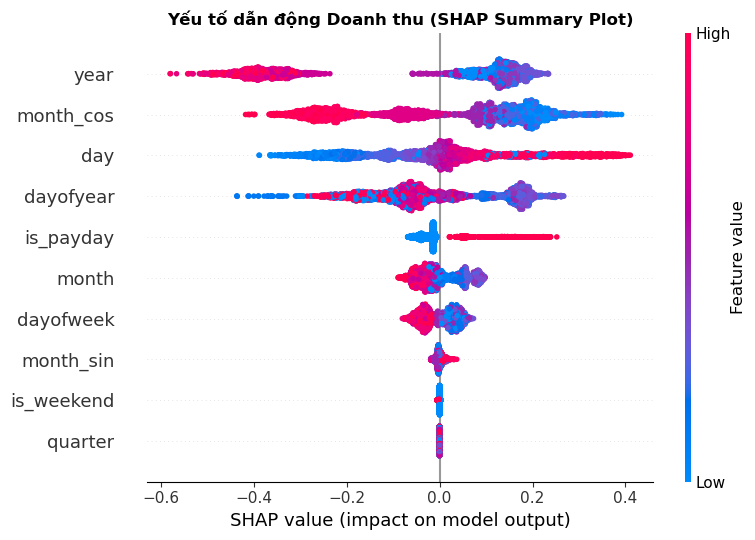

In [8]:
print("--- TẠO SHAP SUMMARY PLOT CHO REVENUE ---")
explainer = shap.TreeExplainer(models_rev['lgb'][-1])
shap_values = explainer.shap_values(X_train_full[FEATURES])

plt.figure(figsize=(10, 6))
plt.title("Yếu tố dẫn động Doanh thu (SHAP Summary Plot)", fontweight='bold')
shap.summary_plot(shap_values, X_train_full[FEATURES], show=False)
plt.tight_layout()
plt.savefig('shap_revenue_drivers.png', dpi=300, bbox_inches='tight')
print("Đã lưu -> shap_revenue_drivers.png")



## 6. Dự báo Ensemble & Ràng Buộc


In [9]:
print("\n--- DỰ BÁO VÀ ENSEMBLE ---")

def predict_ensemble(models_dict):
    all_preds = []
    for m in models_dict['lgb']: all_preds.append(np.expm1(m.predict(X_test[FEATURES])))
    for m in models_dict['xgb']: all_preds.append(np.expm1(m.predict(X_test[FEATURES])))
    for m in models_dict['cat']: all_preds.append(np.expm1(m.predict(X_test[FEATURES])))
    return np.mean(all_preds, axis=0)

test_preds_rev = predict_ensemble(models_rev)
test_preds_cogs = predict_ensemble(models_cogs)

# Ràng buộc tài chính (Không đổi)
test_preds_rev = np.clip(test_preds_rev, 0, None)
test_preds_cogs = np.clip(test_preds_cogs, 0, None)
test_preds_cogs = np.minimum(test_preds_cogs, test_preds_rev)

submission = pd.DataFrame({
    'Date': test_df['Date'].dt.strftime('%Y-%m-%d'),
    'Revenue': test_preds_rev.round(2),
    'COGS': test_preds_cogs.round(2),
})

submission.to_csv('submission.csv', index=False)
print("Hoàn thành! -> submission.csv")
print(submission.head())




--- DỰ BÁO VÀ ENSEMBLE ---
Hoàn thành! -> submission.csv
         Date     Revenue        COGS
0  2023-01-01  3344762.08  2910728.06
1  2023-01-02  1944216.33  1626274.33
2  2023-01-03  1781619.47  1478823.90
3  2023-01-04  1547465.05  1242531.92
4  2023-01-05  1653158.78  1332032.44


--- VẼ BIỂU ĐỒ DỰ BÁO REVENUE ---


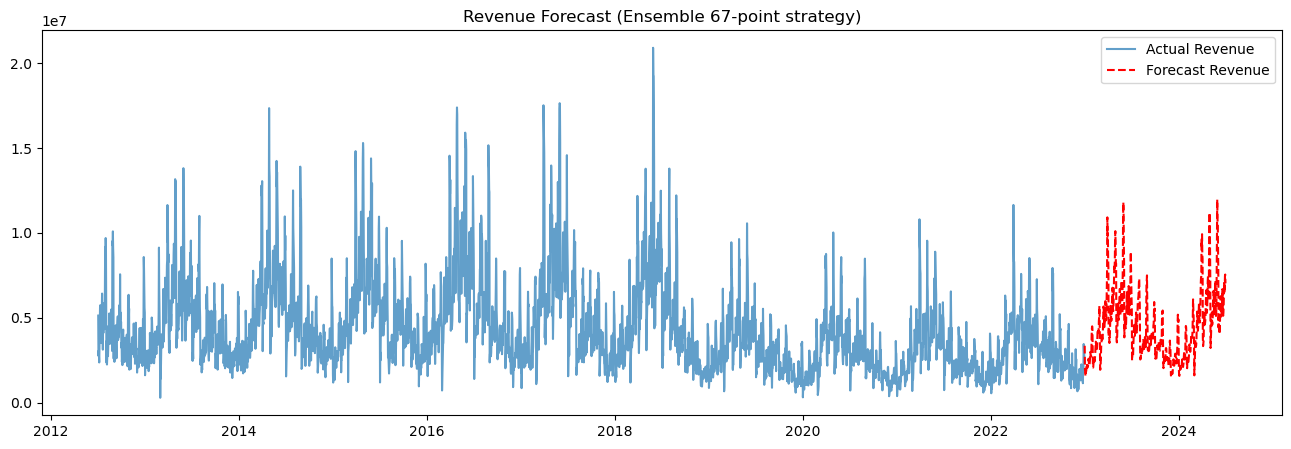

Đã lưu -> forecast_revenue.png


In [10]:
print('--- VẼ BIỂU ĐỒ DỰ BÁO REVENUE ---')
plt.figure(figsize=(16, 5))
plt.plot(train_df['Date'], train_df['Revenue'], label='Actual Revenue', alpha=0.7)
plt.plot(test_df['Date'], test_preds_rev, label='Forecast Revenue', color='red', linestyle='--')
plt.title('Revenue Forecast (Ensemble 67-point strategy)')
plt.legend()
plt.savefig('forecast_revenue.png', bbox_inches='tight')
plt.show()
print('Đã lưu -> forecast_revenue.png')

--- VẼ BIỂU ĐỒ DỰ BÁO COGS ---


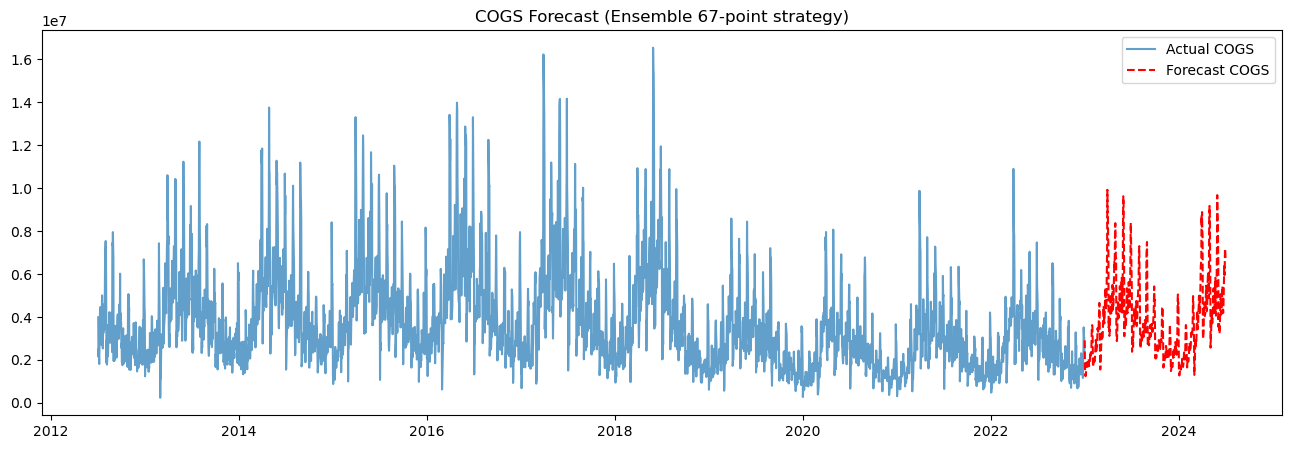

Đã lưu -> forecast_cogs.png


In [11]:
print('--- VẼ BIỂU ĐỒ DỰ BÁO COGS ---')
plt.figure(figsize=(16, 5))
plt.plot(train_df['Date'], train_df['COGS'], label='Actual COGS', alpha=0.7)
plt.plot(test_df['Date'], test_preds_cogs, label='Forecast COGS', color='red', linestyle='--')
plt.title('COGS Forecast (Ensemble 67-point strategy)')
plt.legend()
plt.savefig('forecast_cogs.png', bbox_inches='tight')
plt.show()
print('Đã lưu -> forecast_cogs.png')

--- TẠO SHAP SUMMARY PLOT CHO COGS ---


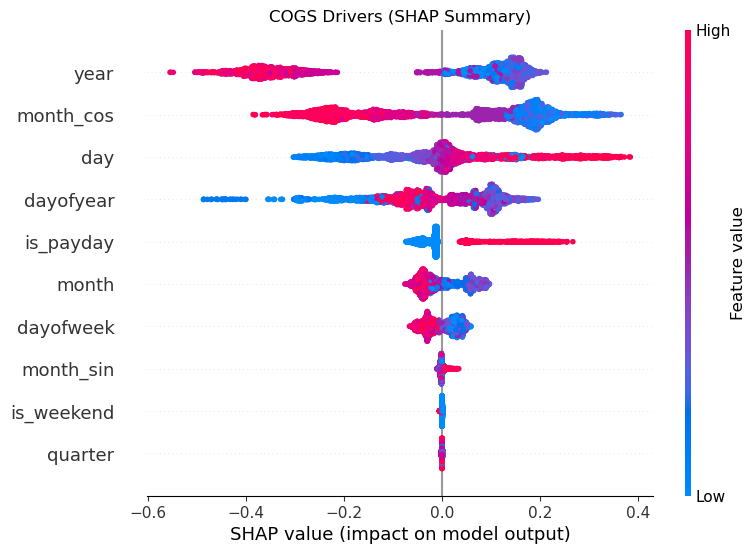

Đã lưu -> shap_cogs_drivers.png


In [12]:
print('--- TẠO SHAP SUMMARY PLOT CHO COGS ---')
explainer_cogs = shap.TreeExplainer(models_cogs['lgb'][-1])
shap_values_cogs = explainer_cogs.shap_values(X_train_full[FEATURES])
shap.summary_plot(shap_values_cogs, X_train_full[FEATURES], show=False)
plt.title('COGS Drivers (SHAP Summary)')
plt.savefig('shap_cogs_drivers.png', bbox_inches='tight')
plt.show()
print('Đã lưu -> shap_cogs_drivers.png')